## **Patch Dataset Creation**

In [1]:
import os
print("Current working directory:", os.getcwd())


Current working directory: c:\Users\USER\Documents\FloodRisk-Ibadan-DeepLearning\experiments


In [2]:
%pwd

'c:\\Users\\USER\\Documents\\FloodRisk-Ibadan-DeepLearning\\experiments'

In [3]:
os.chdir("../")

In [4]:
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\USER\Documents\FloodRisk-Ibadan-DeepLearning


In [12]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window
from sklearn.model_selection import train_test_split

# ==== CONFIGURATION ====
INPUT_STACK = r"data\Ibadan_Flood_Project\Sentinel_Stacks\scene7_rainy_stack.tif"   # example Sentinel-2 stack
INPUT_MASK  = r"data\Ibadan_Flood_Project\Masks\scene7_rainy_label.tif"            # corresponding mask
PATCH_SIZE = 256                                              # tile size (256x256)
OUTPUT_DIR = "dataset/tiles/"

# Create output folders
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "masks"), exist_ok=True)

# ==== STEP 1: Load data ====
with rasterio.open(INPUT_STACK) as src_img, rasterio.open(INPUT_MASK) as src_mask:
    img_array = src_img.read()   # shape: (bands, H, W)
    mask_array = src_mask.read(1)  # single band (H, W)

print("Image shape:", img_array.shape)  # e.g. (6 bands, 3000, 3000)
print("Mask shape:", mask_array.shape)

# ==== STEP 2: Extract patches ====
patches_img = []
patches_mask = []

height, width = mask_array.shape

for i in range(0, height, PATCH_SIZE):
    for j in range(0, width, PATCH_SIZE):
        # Crop window
        img_patch = img_array[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
        mask_patch = mask_array[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
        
        # Skip if patch is smaller than desired size (edge tiles)
        if img_patch.shape[1] != PATCH_SIZE or img_patch.shape[2] != PATCH_SIZE:
            continue
        
        # Skip patches with no water at all (optional, reduces imbalance)
        if mask_patch.sum() == 0:
            continue
        
        patches_img.append(img_patch)
        patches_mask.append(mask_patch)

print(f"Total patches extracted: {len(patches_img)}")

# ==== STEP 3: Split train/val/test ====
train_idx, test_idx = train_test_split(range(len(patches_img)), test_size=0.2, random_state=42)
train_idx, val_idx  = train_test_split(train_idx, test_size=0.1, random_state=42)

def save_patches(indices, split):
    for k, idx in enumerate(indices):
        np.save(os.path.join(OUTPUT_DIR, split, "images", f"img_{k}.npy"), patches_img[idx])
        np.save(os.path.join(OUTPUT_DIR, split, "masks", f"mask_{k}.npy"), patches_mask[idx])

save_patches(train_idx, "train")
save_patches(val_idx, "val")
save_patches(test_idx, "test")

print("✅ Patches saved into dataset/tiles/ folder")


Image shape: (6, 1251, 1134)
Mask shape: (1251, 1134)
Total patches extracted: 10
✅ Patches saved into dataset/tiles/ folder


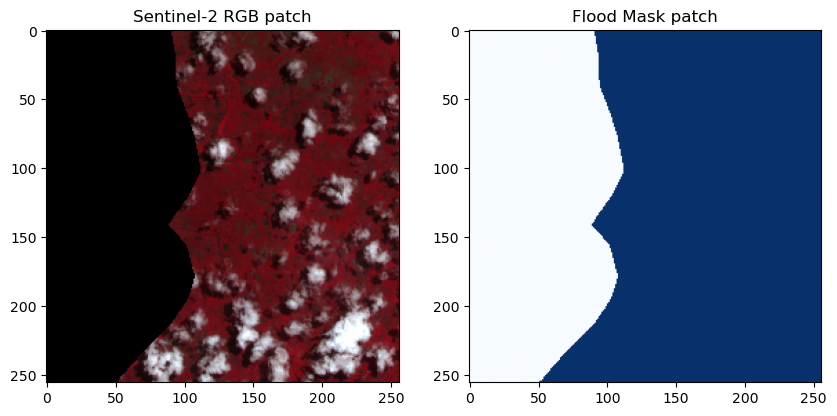

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Load one saved patch
img_patch = np.load("dataset/tiles/train/images/img_0.npy")  # shape: (6, 256, 256)
mask_patch = np.load("dataset/tiles/train/masks/mask_0.npy") # shape: (256, 256)

# Pick RGB bands (B4=Red, B3=Green, B2=Blue → indexes 3,2,1)
rgb = np.transpose(img_patch[[3,2,1], :, :], (1,2,0))

# Normalize for display
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("Sentinel-2 RGB patch")

plt.subplot(1,2,2)
plt.imshow(mask_patch, cmap="Blues")
plt.title("Flood Mask patch")

plt.show()


## **PyTorch Dataset Class**

In [15]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

class FloodDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        """
        Args:
            image_dir (str): path to image patches (numpy arrays).
            mask_dir (str): path to mask patches (numpy arrays).
            transform (albumentations.Compose): augmentations to apply.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image and mask
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = np.load(image_path)  # shape: (C, H, W)
        mask = np.load(mask_path)    # shape: (H, W)

        # Convert to float32 for PyTorch
        image = image.astype(np.float32)
        mask = mask.astype(np.float32)

        # Transpose image to (H, W, C) for Albumentations
        image = np.transpose(image, (1, 2, 0))

        # Apply augmentations (if any)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Convert to tensors if no augmentation
            image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
            mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask


ImportError: DLL load failed while importing _C: The operating system cannot run %1.